# 01 — Data loading & sanity checks
Load the raw `.txt` files, check them, save typed parquets. No modeling decisions here;
everything downstream depends on the column schema, unit counts and regime structure.

Note: *training trajectories end at failure*, so the train set
is contaminated with anomalous late-life cycles. The healthy reference is built in notebook 02.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.loaders import load, load_rul, COLS, SENSORS_ALL

SUBSETS = ['FD001', 'FD002', 'FD003', 'FD004']

## Load all subsets and run sanity assertions

In [2]:
summary = []
for fd in SUBSETS:
    tr, te, rul = load(fd, 'train'), load(fd, 'test'), load_rul(fd)
    # --- assertions, not comments ---
    assert tr.isna().sum().sum() == 0 and te.isna().sum().sum() == 0, 'missing values!'
    assert (np.sort(tr.unit.unique()) == np.arange(1, tr.unit.nunique() + 1)).all()
    for df in (tr, te):
        assert (df.groupby('unit')['cycle'].apply(lambda c: (c.values == np.arange(1, len(c) + 1)).all())).all(), 'non-contiguous cycles'
    assert len(rul) == te.unit.nunique()
    g = tr.groupby('unit')['cycle'].max()
    summary.append(dict(subset=fd, train_units=tr.unit.nunique(), test_units=te.unit.nunique(),
                        train_rows=len(tr), test_rows=len(te),
                        len_min=int(g.min()), len_mean=round(float(g.mean()), 1), len_max=int(g.max()),
                        rul_min=int(rul.min()), rul_max=int(rul.max())))
summary = pd.DataFrame(summary).set_index('subset')
summary.to_csv('../results/tables/subset_summary.csv')
summary

,train_units,test_units,train_rows,test_rows,len_min,len_mean,len_max,rul_min,rul_max
subset,,,,,,,,,
FD001,100,100,20631,13096,128,206.3,362,7,145
FD002,260,259,53759,33991,128,206.8,378,6,194
FD003,100,100,24720,16596,145,247.2,525,6,145
FD004,249,248,61249,41214,128,246.0,543,6,195


**Readme discrepancy:** the official readme states FD004 has
248 train / 249 test units; the actual files contain **249 train / 248 test**. Verified above.

In [3]:
print('FD004 from files: train units =', summary.loc['FD004','train_units'],
      '| test units =', summary.loc['FD004','test_units'], ' (readme claims 248/249)')

FD004 from files: train units = 249 | test units = 248  (readme claims 248/249)


## Operating regimes: 1 (FD001/FD003) vs 6 (FD002/FD004)

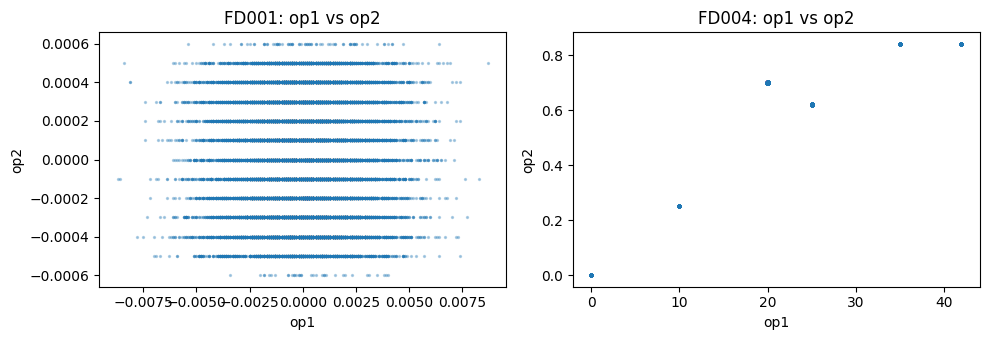

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, fd in zip(axes, ['FD001', 'FD004']):
    d = load(fd)
    ax.scatter(d.op1, d.op2, s=2, alpha=.3)
    ax.set(title=f'{fd}: op1 vs op2', xlabel='op1', ylabel='op2')
plt.tight_layout(); plt.savefig('../results/figures/01_regimes.png', dpi=120); plt.show()

FD001 collapses to a single blob (one regime, sea level); FD004 shows **six separated clusters**
— regime structure is trivially recoverable, which notebook 04 exploits with KMeans(6).

In [5]:
# constant sensors per subset (global): zero variance ⇒ zero information
for fd in ['FD001', 'FD003']:
    tr = load(fd)
    const = [s for s in SENSORS_ALL if tr[s].std() < 1e-6]
    print(fd, 'constant sensors:', const)

FD001 constant sensors: ['s1', 's5', 's10', 's16', 's18', 's19']
FD003 constant sensors: ['s1', 's5', 's16', 's18', 's19']


In [6]:
# persist typed parquets for downstream notebooks
for fd in SUBSETS:
    load(fd, 'train').to_parquet(f'../data/processed/{fd}_train.parquet')
    load(fd, 'test').to_parquet(f'../data/processed/{fd}_test.parquet')
print('parquets written.')

parquets written.
